<a href="https://colab.research.google.com/github/alyssaiapalucci4/Lesson_10_amazon-alexa-sentiment-analysis/blob/main/Lesson_10_Assignment_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lesson 10 Assignment – AI Sentiment Analysis

### Name: Alyssa Iapalucci
### Date: June 27, 2026  
---

### Project Overview

This project focuses on building a sentiment analysis model using machine learning techniques to classify customer reviews as positive or negative. The dataset was preprocessed, cleaned, and transformed before training a model to make predictions.

---

##### Google Colab Notebook:
https://colab.research.google.com/drive/1Fpa9wy16V4rpgw81-j3bwMe36uQt32dQ?usp=sharing

---

##### GitHub Repository:
https://github.com/alyssaiapalucci4/Lesson_10_amazon-alexa-sentiment-analysis

---

### Tools & Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Scikit-learn
- Matplotlib / Seaborn

---

### Summary

This assignment demonstrates the full machine learning workflow including data preprocessing, feature engineering, model training, and evaluation for sentiment classification.

---

In [ ]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# ============================================
# 2. LOAD DATASET
# ============================================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/amazon_alexa.tsv', sep='\t')

df.head()

Mounted at /content/drive


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [ ]:
# ============================================
# 3. DATA CLEANING
# ============================================
print(df.isnull().sum())
df.dropna(inplace=True)

df.drop(['date', 'rating'], axis=1, inplace=True)

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


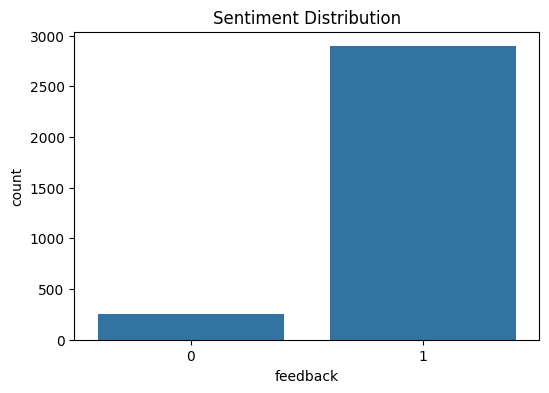

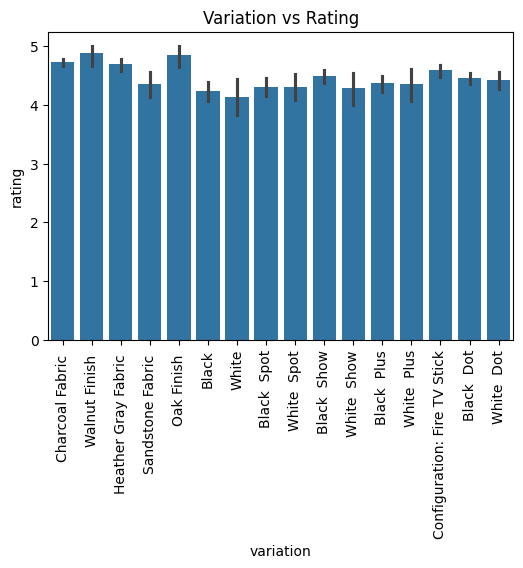

In [ ]:
# ============================================
# 4. VISUALIZATION
# ============================================
plt.figure(figsize=(6,4))
sns.countplot(x='feedback', data=df)
plt.title("Sentiment Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x='variation', y='rating', data=pd.read_csv('/content/amazon_alexa.tsv', sep='\t'))
plt.xticks(rotation=90)
plt.title("Variation vs Rating")
plt.show()

In [ ]:
# ============================================
# 5. FEATURE ENGINEERING (REQUIRED RUBRIC PART)
# ============================================

# TF-IDF (PRIMARY)
tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(df['verified_reviews'])
y = df['feedback']

In [ ]:
# OPTIONAL: Bag of Words (for rubric requirement)

bow = CountVectorizer(stop_words='english')
X_bow = bow.fit_transform(df['verified_reviews'])

In [ ]:
# ============================================
# 6. TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ============================================
# 7. TRAIN MODELS (REQUIRED)
# ============================================

# Logistic Regression (with tuning)
lr = LogisticRegression(max_iter=1000)

params = {"C": [0.1, 1, 10]}

grid_lr = GridSearchCV(lr, params, cv=3)
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

In [ ]:
# SVM

svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [ ]:
# Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# ============================================
# 8. EVALUATION FUNCTION (CLEAN & SAFE)
# ============================================

def evaluate(model, X_test, y_test, name):

    preds = model.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name + " Confusion Matrix")
    plt.show()


 Logistic Regression
Accuracy: 0.9238095238095239
              precision    recall  f1-score   support

           0       0.86      0.29      0.43        63
           1       0.93      0.99      0.96       567

    accuracy                           0.92       630
   macro avg       0.89      0.64      0.69       630
weighted avg       0.92      0.92      0.91       630



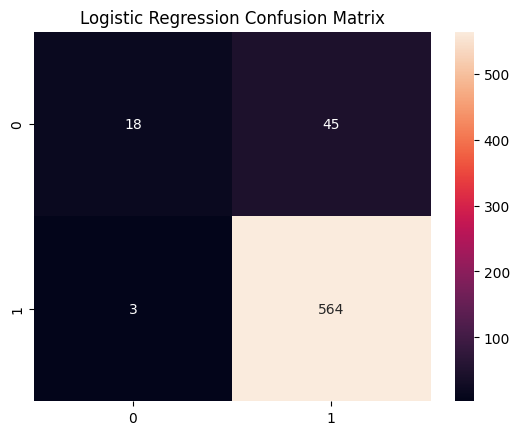

In [ ]:
# Logistic Regression

evaluate(best_lr, X_test, y_test, "Logistic Regression")


 SVM
Accuracy: 0.9142857142857143
              precision    recall  f1-score   support

           0       1.00      0.14      0.25        63
           1       0.91      1.00      0.95       567

    accuracy                           0.91       630
   macro avg       0.96      0.57      0.60       630
weighted avg       0.92      0.91      0.88       630



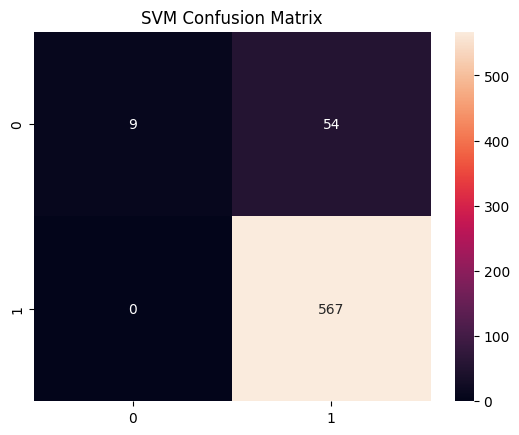

In [ ]:
# SVM

evaluate(svm, X_test, y_test, "SVM")


 Random Forest
Accuracy: 0.9222222222222223
              precision    recall  f1-score   support

           0       1.00      0.22      0.36        63
           1       0.92      1.00      0.96       567

    accuracy                           0.92       630
   macro avg       0.96      0.61      0.66       630
weighted avg       0.93      0.92      0.90       630



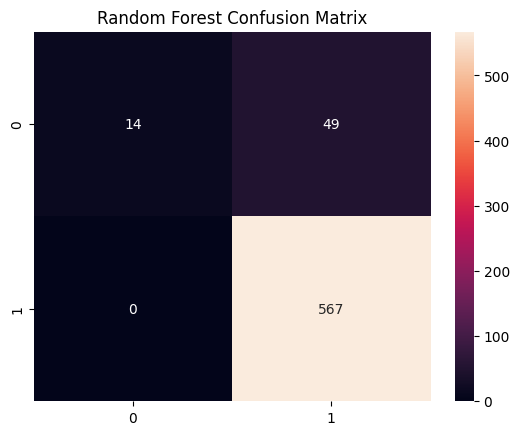

In [ ]:
# Random Forest

evaluate(rf, X_test, y_test, "Random Forest")

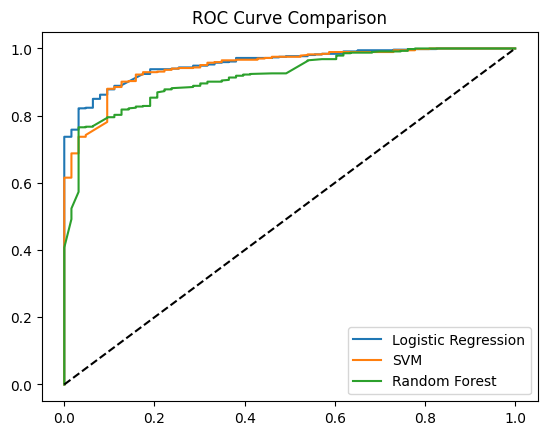

In [ ]:
# ============================================
# 9. ROC CURVE (REQUIRED)
# ============================================

from sklearn.metrics import roc_curve

plt.figure()

for name, model in {
    "Logistic Regression": best_lr,
    "SVM": svm,
    "Random Forest": rf
}.items():

    # safe probability handling
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:,1]
    else:
        probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

       feature  importance
3365  terrible    0.016156
2820    return    0.014152
3222   stopped    0.012905
3736   working    0.012338
957       didn    0.011499
2029      love    0.009642
3732      work    0.009542
1528      half    0.009113
1038     doesn    0.008511
2495      poor    0.007832


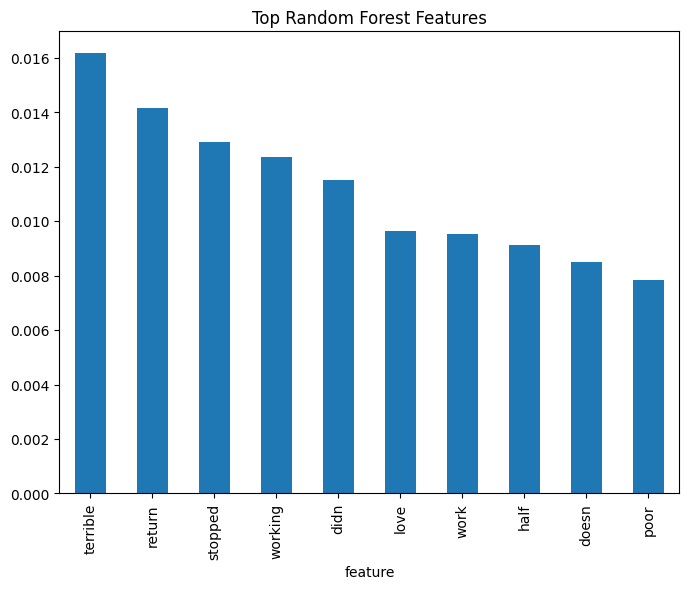

In [ ]:
# ============================================
# 10. FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================

importances = rf.feature_importances_
feature_names = tfidf.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df.head(10))

importance_df.head(10).plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(8,6),
    legend=False
)

plt.title("Top Random Forest Features")
plt.show()

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.1 MB/s eta 0:00:00


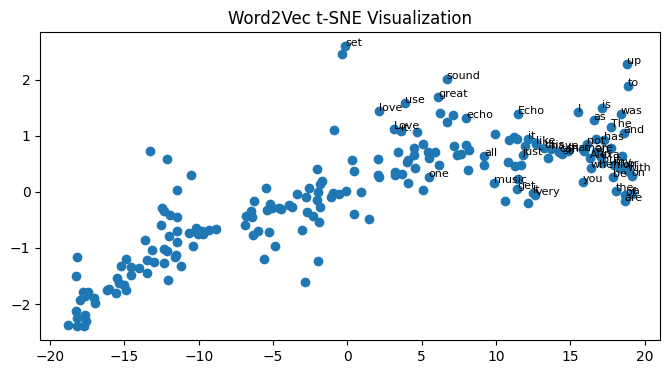

In [ ]:
# ============================================
# 11 & 12 WORD2VEC + t-SNE
# ============================================

from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Train Word2Vec (your dataset)
sentences = df['verified_reviews'].apply(lambda x: x.split()).tolist()

w2v = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# Get word vectors
words = list(w2v.wv.index_to_key)

# limit size for speed (IMPORTANT for Colab stability)
words_sample = words[:200]

vectors = np.array([w2v.wv[word] for word in words_sample])

# t-SNE reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(vectors)

# Plot
plt.figure(figsize=(8,4))
plt.scatter(reduced[:,0], reduced[:,1])

for i, word in enumerate(words_sample[:50]):  # label only first 50
    plt.annotate(word, (reduced[i,0], reduced[i,1]), fontsize=8)

plt.title("Word2Vec t-SNE Visualization")
plt.show()

In [ ]:
# ============================================
# 13. SIMPLE BERT (SAFE VERSION - NO TRAINING)
# ============================================

from transformers import pipeline

bert = pipeline("sentiment-analysis")

print(bert("I love this Alexa device!"))

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998435974121094}]


In [ ]:
# ============================================
# 14. NEW PREDICTION FUNCTION
# ============================================

def predict_sentiment(text):
    vec = tfidf.transform([text])
    pred = rf.predict(vec)
    return "Positive" if pred[0] == 1 else "Negative"

print(predict_sentiment("This product is amazing"))

Positive
